Feature Scaling --> Min Max Normalization

x(Scaled) = x(i) - x(min) / x(max)-x(min)

In [1]:
import numpy as np
import pandas as pd
import sklearn

In [2]:
data = pd.DataFrame({'Price_USA':[80,50,140,25],
                     'Price_INR':[5000,7000,12000,3000]})
data

,Price_USA,Price_INR
0,80,5000
1,50,7000
2,140,12000
3,25,3000


In [3]:
data['Price_USA_minmax'] = (data['Price_USA']-data['Price_USA'].min())/(data['Price_USA'].max() - data['Price_USA'].min())
data

,Price_USA,Price_INR,Price_USA_minmax
0,80,5000,0.478261
1,50,7000,0.217391
2,140,12000,1.000000
3,25,3000,0.000000


In [4]:
data['Price_INR_minmax'] = (data['Price_INR']-data['Price_INR'].min())/(data['Price_INR'].max() - data['Price_INR'].min())
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax
0,80,5000,0.478261,0.222222
1,50,7000,0.217391,0.444444
2,140,12000,1.000000,1.000000
3,25,3000,0.000000,0.000000


In [5]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [6]:
min_max = MinMaxScaler()

In [7]:
data['Price_USA_minsk'] = min_max.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk
0,80,5000,0.478261,0.222222,0.478261
1,50,7000,0.217391,0.444444,0.217391
2,140,12000,1.000000,1.000000,1.000000
3,25,3000,0.000000,0.000000,0.000000


In [8]:
data['Price_INR_minsk'] = min_max.fit_transform(data[['Price_INR']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk,Price_INR_minsk
0,80,5000,0.478261,0.222222,0.478261,0.222222
1,50,7000,0.217391,0.444444,0.217391,0.444444
2,140,12000,1.000000,1.000000,1.000000,1.000000
3,25,3000,0.000000,0.000000,0.000000,0.000000


In [9]:
data['Price_INR_minsk'] = min_max.fit_transform(data[['Price_INR']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk,Price_INR_minsk
0,80,5000,0.478261,0.222222,0.478261,0.222222
1,50,7000,0.217391,0.444444,0.217391,0.444444
2,140,12000,1.000000,1.000000,1.000000,1.000000
3,25,3000,0.000000,0.000000,0.000000,0.000000


In [10]:
std_scaler = StandardScaler()
data['Price_USA_std'] = std_scaler.fit_transform(data[['Price_USA']])
data

,Price_USA,Price_INR,Price_USA_minmax,Price_INR_minmax,Price_USA_minsk,Price_INR_minsk,Price_USA_std
0,80,5000,0.478261,0.222222,0.478261,0.222222,0.145617
1,50,7000,0.217391,0.444444,0.217391,0.444444,-0.553346
2,140,12000,1.000000,1.000000,1.000000,1.000000,1.543544
3,25,3000,0.000000,0.000000,0.000000,0.000000,-1.135815


In [11]:
from sklearn.preprocessing import RobustScaler

In [12]:
!pip install ucimlrepo

In [13]:
#step-1--->import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [14]:
##Step2:Loading(autompg dataset) and cleaning the Data
data= fetch_ucirepo(id=9)
data
X=data.data.features.copy()#it  return all numeric features
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [15]:
y=data.data.targets['mpg']

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB


In [17]:
X['origin'].unique();
X['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [18]:
#first we will transform the horsepower and orgin columns
X['horsepower'] = pd.to_numeric(X['horsepower'], errors='coerce')
#X['horsepower'].info()
X['origin'] = X['origin'].astype(str)

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 21.9+ KB


In [20]:
X.info()
numerical_features = ['cylinders','displacement','horsepower','weight','acceleration','model_year']
categorical_features=['origin']
X=X[numerical_features + categorical_features]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 21.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64 

In [21]:
X.isnull().sum()

,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0


In [22]:
X.shape

(398, 7)

In [23]:
df=X.copy()
df['mpg']=y

In [24]:
df

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0
3,8,304.0,150.0,3433,12.0,70,1,16.0
4,8,302.0,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6,82,1,27.0
394,4,97.0,52.0,2130,24.6,82,2,44.0
395,4,135.0,84.0,2295,11.6,82,1,32.0
396,4,120.0,79.0,2625,18.6,82,1,28.0


Text(0.5, 1.0, 'HorsePower vs MPG Distribution')

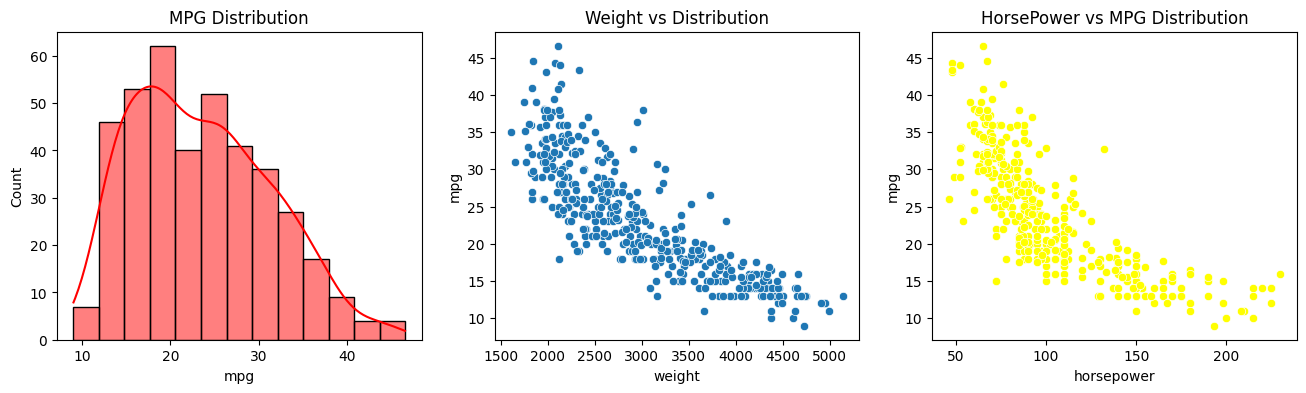

In [25]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
sns.histplot(df['mpg'],kde=True,ax=axes[0],color='red')
axes[0].set_title("MPG Distribution")
sns.scatterplot(x=df['weight'],y=df['mpg'],ax=axes[1])
axes[1].set_title("Weight vs Distribution")
sns.scatterplot(x=df['horsepower'],y=df['mpg'],ax=axes[2],color='yellow')
axes[2].set_title("HorsePower vs MPG Distribution")

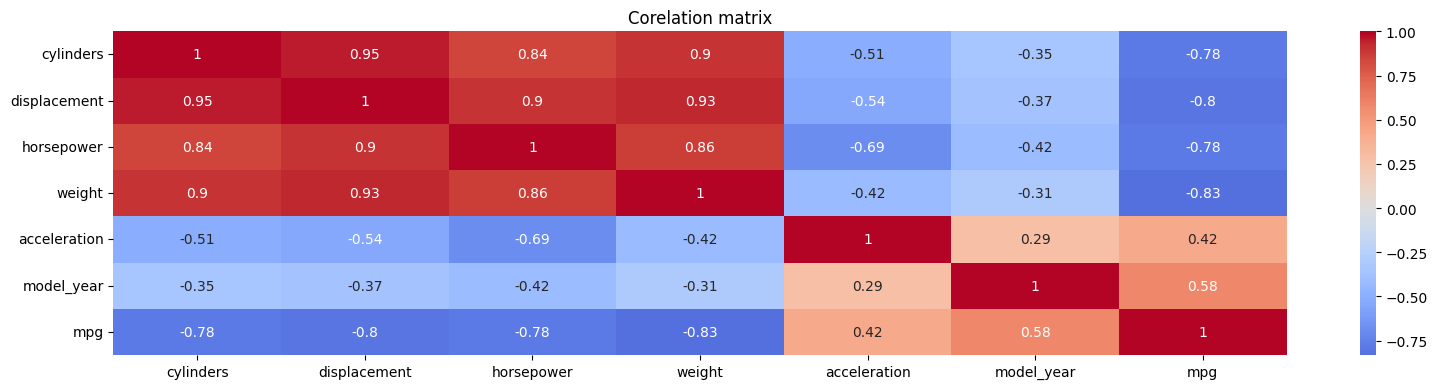

In [26]:
#Corelation between our variables (positive corelation/negative corelation))

plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm',
            center=0
           )
plt.title("Corelation matrix")
plt.tight_layout()
plt.show()


In [27]:
#Step4: Dividing the data into train,test,

print(X)
print(y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print('\n Train test Split')
print("Training Data",len(X_train))
print("Testing Data",len(X_test))

     cylinders  displacement  horsepower  weight  acceleration  model_year  \
0            8         307.0       130.0    3504          12.0          70   
1            8         350.0       165.0    3693          11.5          70   
2            8         318.0       150.0    3436          11.0          70   
3            8         304.0       150.0    3433          12.0          70   
4            8         302.0       140.0    3449          10.5          70   
..         ...           ...         ...     ...           ...         ...   
393          4         140.0        86.0    2790          15.6          82   
394          4          97.0        52.0    2130          24.6          82   
395          4         135.0        84.0    2295          11.6          82   
396          4         120.0        79.0    2625          18.6          82   
397          4         119.0        82.0    2720          19.4          82   

    origin  
0        1  
1        1  
2        1  
3        1 

In [28]:
#Step5 Create an evaluation function for baseline model

def evaluate(model_name,actual,predicted):
    """Return MAE,MSE,RMSE,R2-Score"""
    mse = mean_squared_error(actual,predicted)
    mae=mean_absolute_error(actual,predicted)
    return {'Model_Name': model_name,
    'MAE': mae,
    'MSE': mse,
    'RMSE': np.sqrt(mse),
    'R2-Score': r2_score(actual,predicted)}
results=[]

In [29]:
#Step6 Baseline model---> It predicts the training set for every values

baseline_predictions = np.full(len(y_test),y_train.mean())
#baseline_predictions
results.append(evaluate("Mean baseline",y_test,baseline_predictions))
results

[{'Model_Name': 'Mean baseline',
  'MAE': 5.955408805031446,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686}]

In [30]:
#Step7 We apply Linear Regression

simple_model =LinearRegression()
simple_model.fit(X_train[['weight']],y_train)
simple_model_predictions = simple_model.predict(X_test[['weight']])
#print(simple_model_predictions)
results.append(evaluate("Simple Linear Regression Weight",y_test,simple_model_predictions))
print(len(results))

2


In [31]:
#we will check the intercept value
print(f'Simple Linear Regression Equation')
print(f"Predicted MPG={simple_model.intercept_}+{simple_model.coef_[0]}*weight")

Simple Linear Regression Equation
Predicted MPG=46.78206336645047+-0.00780524235159488*weight


In [32]:
#try with the below columns
#cylinder
#horsepower
#displacement
#find evaluation metric for Linear REGRESSION